# E11e: Phase Shift in AC Circuits
# Yaman Ajaj (3722952) ;  Guilherme Schewtschik (3748052)

## 1. Setup:
The experiment investigates the phase shift between voltage and current in three different AC circuits: RLC, RC, and RL series circuits. The components include resistors, capacitors, and inductors, and the setup is powered by an arbitrary waveform generator. The voltage across the resistor (in-phase with current) and the total voltage are measured using a two-channel oscilloscope.
We connected the AWG to the circuit and we kept on varying the frequency until we saw that the waves were in phase, meaning that is the resonance frequency. We then took measurements around that frequency and we recorded the time difference between the two signals. We did this for the three different circuits.

## 2. Theoretical Background:
n AC circuits, phase shifts occur due to the reactive components—capacitors and inductors. The impedance and corresponding phase angle (φ) for each circuit type are given by:
- Resistor (R): No phase shift.
- Capacitor (C): $Z_C = \frac{1}{j\omega C}$, causes current to lead the voltage $(ϕ<0)$.
- Inductor (L): $Z_L = j\omega L$,  causes current to lag voltage $(ϕ>0)$.

For series circuits:
- RC Circuit: $\phi = -\tan^{-1}\left(\frac{1}{\omega RC}\right)$
- RL Circuit: $\phi = \tan^{-1}\left(\frac{\omega L}{R}\right)$
- RLC Circuit: $\phi = \tan^{-1}\left(\frac{\omega L - \frac{1}{\omega C}}{R}\right)$

The angular frequency is:
$$\omega = 2\pi f$$

The phase shift $\phi$ can be calculated from the time delay Δt using:
$$\phi = \omega \Delta t$$
Where:
- f is the frequency in Hz.
- Δt is the time delay in seconds.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit 

#functions
def line(x, a, b):
    return a*x+b

#data import
data_1 = pd.read_excel('Data.xlsx', sheet_name='RLC')
data_2 = pd.read_excel('Data.xlsx', sheet_name='RL')
data_3 = pd.read_excel('Data.xlsx', sheet_name='RC')
data_4 = pd.read_excel('Data.xlsx', sheet_name='things')

data_RLC = data_1.to_numpy()
data_RL = data_2.to_numpy()
data_RC = data_3.to_numpy()
data_m = data_4.to_numpy()

#asserting variables
L , C , R_c, R_r = data_m[0,0]*1e-3, data_m[0,1]*1e-6, data_m[0,2], data_m[0,3]
f_RLC, dt_RLC, rs_f = data_RLC[:,0]*1e3 , data_RLC[:,1]*1e-6,  data_RLC[0,3]*1e3
f_RL, dt_RL= data_RL[:,0]*1e3 , data_RL[:,1]*1e-6
f_RC, dt_RC = data_RC[:,0]*1e3 , data_RC[:,1]*1e-6


#calculating the phase shift and omega
omega_RC = 2*np.pi*f_RC
phi_RC = omega_RC*dt_RC

omega_RLC = 2*np.pi*f_RLC
phi_RLC = omega_RLC*dt_RLC

omega_RL = 2*np.pi*f_RL
phi_RL = omega_RL*dt_RL


Plotting the phase shift for all circuits:

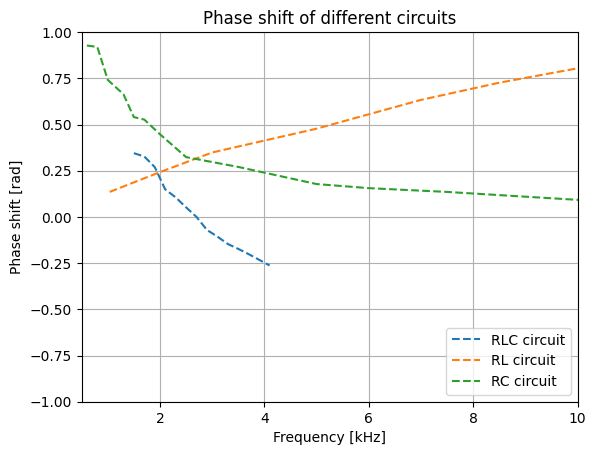

In [38]:
plt.title('Phase shift of different circuits')
plt.xlim((0.5,10))
plt.ylim((-1,1))
plt.xlabel('Frequency [kHz]')
plt.ylabel('Phase shift [rad]')
plt.grid(True)

plt.plot(f_RLC*1e-3, phi_RLC, '--', label='RLC circuit')
plt.plot(f_RL*1e-3, phi_RL, '--', label='RL circuit')
plt.plot(f_RC*1e-3, phi_RC, '--', label='RC circuit')

plt.legend(loc = 'lower right')
plt.show()

### Series Resistance of RC Circuit:
From the RC phase shift equation:
$$tan(|\phi|) = \frac{1}{\omega RC} \implies R = \frac{1}{\omega C tan(|\phi|)}$$

The resistance of the resistor used n the RC circuit is:
$$R_r = 328.80 Ω$$

In [34]:
#resistance RC circuit
R_RC = np.mean(1/(np.tan(phi_RC)*omega_RC*C))

print(f'calculated resistance: R = {"%.3f"%(R_RC)} Ω')
print(f'error resistance: {"%.3f"%(((R_RC-R_r)/R_r)*1e2)}%')


calculated resistance: R = 330.231 Ω
error resistance: 0.435%


### Inductance of the Coil:
i) From RLC Resonance
$$f_0 = \frac{1}{2\pi\sqrt{LC}} \implies L = \frac{1}{4\pi^2f_0^2C}$$


The resonance frequency measured experimentaly is:

$$f_0 = 2.68 kHz$$

We can also calculate the resonance frequency by fitting a line to the phase shift around the experimental value:

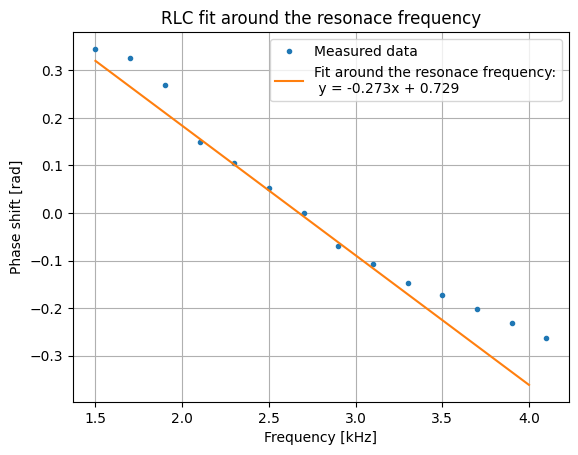

In [ ]:
#fitting a line around the resonance frequency
mask1 = (f_RLC < 3000)&(f_RLC > 2000)

p,c = curve_fit(line, f_RLC[mask1] , phi_RLC[mask1])

x = np.arange(min(f_RLC), max(f_RLC), 100)
fit1 = line(x, *p)

plt.figure(2)
plt.title('RLC fit around the resonace frequency')
plt.xlabel('Frequency [kHz]')
plt.ylabel('Phase shift [rad]')
plt.grid(True)

plt.plot(f_RLC*1e-3, phi_RLC, '.', label='Measured data')
plt.plot(x*1e-3, fit1, '-' , label = f'Fit around the resonace frequency:\n y = {"%.3f"%(p[0]*1e3)}x + {"%.3f"%(p[1])}')

plt.legend(loc = 'upper right')
plt.show()

In [22]:
#fit data
rs_f_fit = -p[1]/p[0] #calculated resonance frequency

L_fit_RLC = 1/(C*((2*np.pi*rs_f_fit)**2))

print(f'Measured resonace frequency: {rs_f*1e-3} kHz, Fitted resonance frequency: {"%.3f"%(rs_f_fit*1e-3)} kHz,\nMeasured Inductance = {L*1e3} mH , Fitted Inductance = {"%.3f"%(L_fit_RLC*1e3)} mH')
print(f'error resonance frequency: {"%.3f"%(((rs_f_fit-rs_f)/rs_f)*1e2)}%')
print(f'error inductance: {"%.3f"%(((L_fit_RLC-L)/L)*1e2)}%')

Measured resonace frequency: 2.68 kHz, Fitted resonance frequency: 2.673 kHz,
Measured Inductance = 6.77 mH , Fitted Inductance = 6.751 mH
error resonance frequency: -0.246%
error inductance: -0.285%


ii) From RL Phase fit:
$$\phi = \tan^{-1}\left(\frac{\omega L}{R}\right)$$
$$L = \frac{tan(\phi)R}{\omega}$$

In [25]:
L_fit_RL = np.mean(np.tan(phi_RL)*(R_r/omega_RL))

print(f'Fitted Inductance = {"%.3f"%(L_fit_RL*1e3)} mH')
print(f'error inductance: {"%.3f"%(((L_fit_RL-L)/L)*1e2)}%')

Fitted Inductance = 5.633 mH
error inductance: -16.795%


###  Fitting the Phase Shift of the RLC Circuit
We fit the RLC model using:
$$\phi = \tan^{-1}\left(\frac{\omega L - \frac{1}{\omega C}}{R}\right)$$

## References:
- Tipler, Physics, 3rd Edition, Vol. 2, Sections 23-2, 28-2, 28-3, 28-5
- Demtröder, Electrodynamics and Optics, Sections 5.2, 5.4, 5.5